📂 MEMUAT DATASET
✅ Dataset berhasil dimuat!
   Jumlah Baris (Mahasiswa): 10,000
   Jumlah Kolom (Atribut): 10
   Ukuran Memori: 2095.46 KB

📋 DAFTAR KOLOM & TIPE DATA
College_ID                 object
IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience      object
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
Placement                  object

Nama Kolom Lengkap:
   1. 'College_ID' - object
   2. 'IQ' - int64
   3. 'Prev_Sem_Result' - float64
   4. 'CGPA' - float64
   5. 'Academic_Performance' - int64
   6. 'Internship_Experience' - object
   7. 'Extra_Curricular_Score' - int64
   8. 'Communication_Skills' - int64
   9. 'Projects_Completed' - int64
   10. 'Placement' - object

🔍 DETEKSI KOLOM PENTING
✅ Kolom Placement ditemukan: 'Placement'
   Nilai unik: ['No' 'Yes']
   Distribusi:
      No: 8341 (83.4%)
      Yes: 1659 (16.6

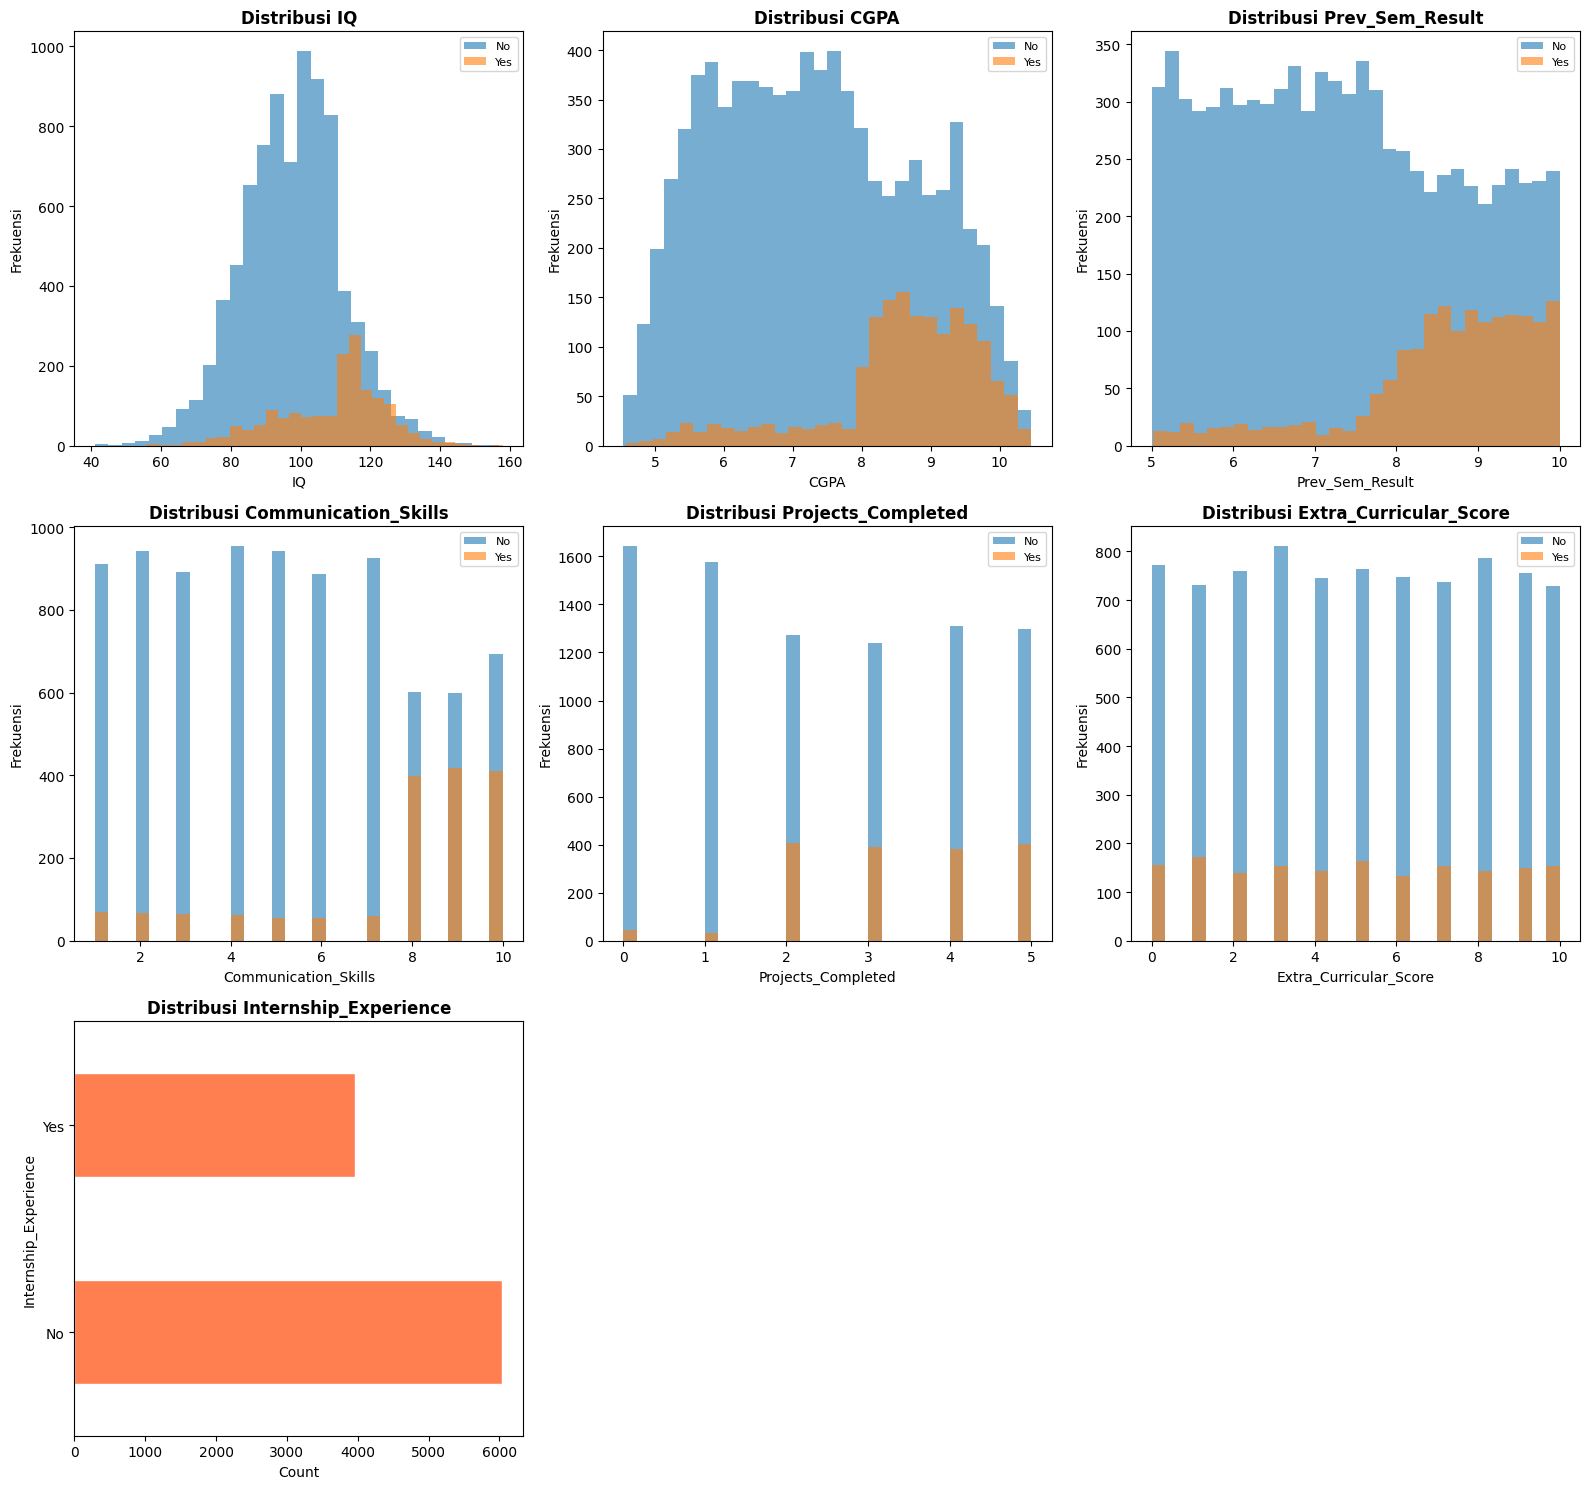

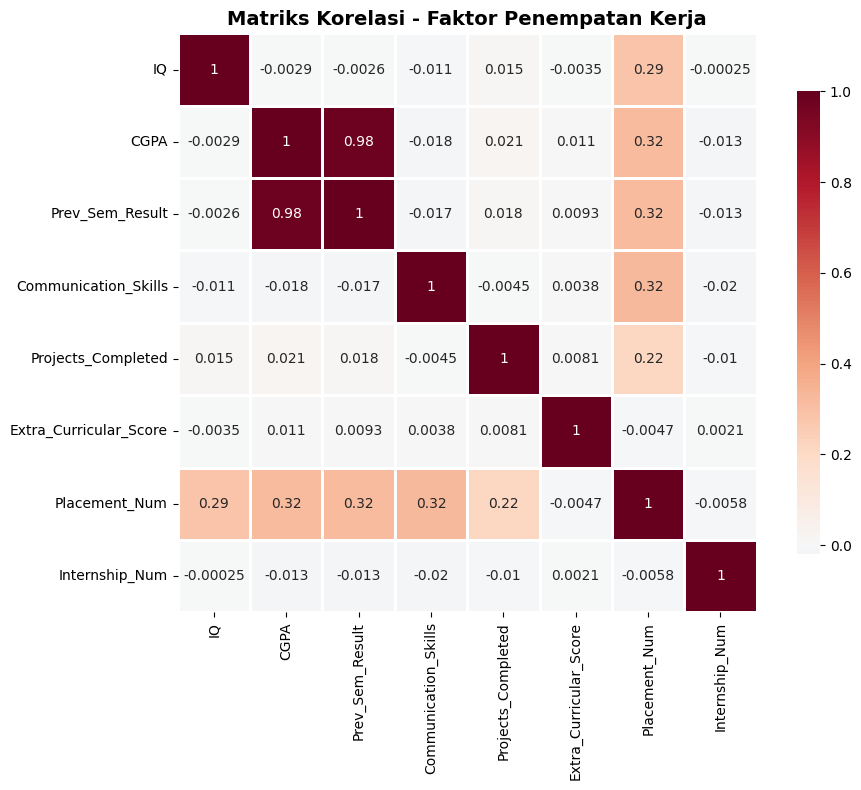

In [2]:
"""
============================================================
ANALISIS DATASET: College Student Placement Factors
Pengecekan Kualitas & Keberagaman Data untuk 6 Visualisasi
(VERSI PERBAIKAN - ERROR KEYERROR TELAH DIATASI)
============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD DATASET
# ============================================================
print("=" * 60)
print("📂 MEMUAT DATASET")
print("=" * 60)

# Sesuaikan path dengan lokasi file Anda
try:
    df = pd.read_csv('data/college_student_placement_dataset.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('college_student_placement_dataset.csv')
    except FileNotFoundError:
        print("❌ File dataset tidak ditemukan!")
        print("   Pastikan file berada di folder 'data/' atau folder yang sama dengan script ini.")
        exit()

print(f"✅ Dataset berhasil dimuat!")
print(f"   Jumlah Baris (Mahasiswa): {len(df):,}")
print(f"   Jumlah Kolom (Atribut): {len(df.columns)}")
print(f"   Ukuran Memori: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# ============================================================
# 2. INFORMASI KOLOM & TIPE DATA
# ============================================================
print("\n" + "=" * 60)
print("📋 DAFTAR KOLOM & TIPE DATA")
print("=" * 60)

print(df.dtypes.to_string())
print(f"\nNama Kolom Lengkap:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. '{col}' - {df[col].dtype}")

# ============================================================
# 3. DETEKSI KOLOM PENTING (DIPERBAIKI)
# ============================================================
print("\n" + "=" * 60)
print("🔍 DETEKSI KOLOM PENTING")
print("=" * 60)

# Deteksi kolom Placement
placement_col = None
for col in df.columns:
    if col.lower() in ['placement', 'placed', 'placement_status', 'status']:
        placement_col = col
        break

if placement_col:
    print(f"✅ Kolom Placement ditemukan: '{placement_col}'")
    print(f"   Nilai unik: {df[placement_col].unique()}")
    print(f"   Distribusi:")
    for val, count in df[placement_col].value_counts().items():
        print(f"      {val}: {count} ({count/len(df)*100:.1f}%)")
else:
    print("❌ Kolom Placement TIDAK DITEMUKAN!")
    print("   Kolom yang tersedia:", list(df.columns))

# Deteksi kolom Internship
internship_col = None
for col in df.columns:
    if 'intern' in col.lower() or 'magang' in col.lower():
        internship_col = col
        break

if internship_col:
    print(f"\n✅ Kolom Internship ditemukan: '{internship_col}'")
    print(f"   Nilai unik: {df[internship_col].unique()}")
else:
    print("\n⚠️ Kolom Internship TIDAK DITEMUKAN!")

# Deteksi kolom College
college_col = None
for col in df.columns:
    if 'college' in col.lower() or 'kampus' in col.lower() or 'univ' in col.lower():
        college_col = col
        break

if college_col:
    print(f"\n✅ Kolom College ditemukan: '{college_col}'")
    print(f"   Jumlah kampus unik: {df[college_col].nunique()}")
else:
    print("\n⚠️ Kolom College TIDAK DITEMUKAN!")

# Deteksi kolom Academic Performance
academic_col = None
for col in df.columns:
    if 'academic' in col.lower():
        academic_col = col
        break

if academic_col:
    print(f"\n✅ Kolom Academic Performance ditemukan: '{academic_col}'")
    print(f"   Nilai unik: {df[academic_col].unique()}")
else:
    print("\n⚠️ Kolom Academic Performance TIDAK DITEMUKAN!")

# Deteksi kolom Extra Curricular
extra_col = None
for col in df.columns:
    if 'extra' in col.lower() or 'curricular' in col.lower() or 'organisasi' in col.lower():
        extra_col = col
        break

if extra_col:
    print(f"\n✅ Kolom Extra Curricular ditemukan: '{extra_col}'")
else:
    print("\n⚠️ Kolom Extra Curricular TIDAK DITEMUKAN!")

# ============================================================
# 4. STATISTIK DESKRIPTIF NUMERIK
# ============================================================
print("\n" + "=" * 60)
print("📊 STATISTIK DESKRIPTIF (Numerik)")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Kolom numerik: {numeric_cols}")
print(df[numeric_cols].describe().round(3).to_string())

# ============================================================
# 5. NILAI UNIK UNTUK KOLOM KATEGORIKAL
# ============================================================
print("\n" + "=" * 60)
print("🏷️ NILAI UNIK KOLOM KATEGORIKAL")
print("=" * 60)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Kolom kategorikal: {categorical_cols}")

for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    print(f"\n{col}:")
    print(f"   Jumlah Unique: {len(unique_vals)}")
    print(f"   Nilai: {', '.join(map(str, unique_vals[:20]))}")
    if len(unique_vals) > 20:
        print(f"   ... dan {len(unique_vals) - 20} nilai lainnya")

# ============================================================
# 6. CEK MISSING VALUES
# ============================================================
print("\n" + "=" * 60)
print("🔍 DETEKSI MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ TIDAK ADA missing values! Dataset lengkap.")
else:
    print("⚠️ Ditemukan missing values:")
    print(missing_df.to_string())

# ============================================================
# 7. CEK DUPLIKASI
# ============================================================
print("\n" + "=" * 60)
print("🔍 DETEKSI DUPLIKASI")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"Jumlah Baris Duplikat: {duplicates} ({duplicates/len(df)*100:.2f}%)")

# ============================================================
# 8. SIAPKAN KOLOM NUMERIK UNTUK HEATMAP (DIPERBAIKI)
# ============================================================
print("\n" + "=" * 60)
print("📊 PERSIAPAN DATA UNTUK HEATMAP KORELASI")
print("=" * 60)

# Identifikasi kolom numerik yang relevan
heatmap_cols = []
for col in ['IQ', 'CGPA', 'Prev_Sem_Result', 'Communication_Skills', 
            'Projects_Completed', 'Extra_Curricular_Score']:
    if col in df.columns and df[col].dtype in ['int64', 'float64']:
        heatmap_cols.append(col)
        print(f"   ✅ {col}: termasuk dalam heatmap")

# Konversi Placement ke numerik JIKA ADA
if placement_col:
    print(f"\n   Memproses kolom Placement: '{placement_col}'")
    # Buat salinan dataframe untuk korelasi
    df_corr = df.copy()
    
    # Konversi placement ke numerik
    placement_mapping = {}
    unique_placement = df_corr[placement_col].unique()
    print(f"   Nilai unik Placement: {unique_placement}")
    
    # Buat mapping otomatis
    for val in unique_placement:
        val_lower = str(val).lower().strip()
        if val_lower in ['placed', 'yes', 'ya', '1', 'true']:
            placement_mapping[val] = 1
        elif val_lower in ['not placed', 'no', 'tidak', '0', 'false']:
            placement_mapping[val] = 0
        else:
            placement_mapping[val] = 0
    
    print(f"   Mapping: {placement_mapping}")
    df_corr['Placement_Num'] = df_corr[placement_col].map(placement_mapping)
    
    # Verifikasi hasil konversi
    print(f"   Hasil konversi Placement_Num:")
    print(f"   - 1 (Placed): {(df_corr['Placement_Num']==1).sum()}")
    print(f"   - 0 (Not Placed): {(df_corr['Placement_Num']==0).sum()}")
    
    heatmap_cols.append('Placement_Num')
    print(f"   ✅ Placement_Num: termasuk dalam heatmap")

# Tambahkan Internship jika numerik atau bisa dikonversi
if internship_col:
    if df_corr[internship_col].dtype in ['int64', 'float64']:
        heatmap_cols.append(internship_col)
        print(f"   ✅ {internship_col}: termasuk dalam heatmap (sudah numerik)")
    else:
        # Konversi ke numerik
        internship_mapping = {}
        for val in df_corr[internship_col].unique():
            val_lower = str(val).lower().strip()
            if val_lower in ['yes', 'ya', '1', 'true', 'intern']:
                internship_mapping[val] = 1
            else:
                internship_mapping[val] = 0
        
        df_corr['Internship_Num'] = df_corr[internship_col].map(internship_mapping)
        heatmap_cols.append('Internship_Num')
        print(f"   ✅ Internship_Num: termasuk dalam heatmap (hasil konversi)")

print(f"\n   Final heatmap columns: {heatmap_cols}")

# ============================================================
# 9. HITUNG KORELASI (DIPERBAIKI)
# ============================================================
print("\n" + "=" * 60)
print("📈 MATRIKS KORELASI")
print("=" * 60)

if len(heatmap_cols) >= 3:
    try:
        corr_matrix = df_corr[heatmap_cols].corr()
        print("\n   Matriks Korelasi:")
        print(corr_matrix.round(3).to_string())
        
        # Cek variasi korelasi
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        corr_values = corr_matrix.values[mask]
        
        if len(corr_values) > 0:
            print(f"\n   Range Korelasi: {corr_values.min():.3f} hingga {corr_values.max():.3f}")
            print(f"   Mean Korelasi: {corr_values.mean():.3f}")
            print(f"   Std Korelasi: {corr_values.std():.3f}")
            
            if corr_values.max() - corr_values.min() < 0.1:
                print("   ⚠️ PERINGATAN: Variasi korelasi sangat kecil! Heatmap akan terlihat monoton.")
            else:
                print("   ✅ Variasi korelasi cukup baik untuk heatmap.")
    except Exception as e:
        print(f"   ❌ Error saat menghitung korelasi: {e}")
else:
    print(f"   ❌ Kolom tidak cukup untuk heatmap (hanya {len(heatmap_cols)} kolom)")

# ============================================================
# 10. ANALISIS KHUSUS UNTUK TIAP VISUALISASI
# ============================================================

# --- VISUALISASI 1: Histogram CGPA vs Placement ---
print("\n" + "-" * 40)
print("1️⃣ HISTOGRAM: Distribusi Peluang Kerja Berdasarkan CGPA")
print("-" * 40)

if 'CGPA' in df.columns:
    print(f"✅ CGPA: min={df['CGPA'].min():.2f}, max={df['CGPA'].max():.2f}, mean={df['CGPA'].mean():.2f}")
    print(f"   Standar Deviasi: {df['CGPA'].std():.2f}")
    
    # Cek distribusi CGPA
    print(f"   Distribusi CGPA per kuartil:")
    for q in [0, 0.25, 0.5, 0.75, 1.0]:
        print(f"      Q{q}: {df['CGPA'].quantile(q):.2f}")
    
    # Cek range CGPA
    cgpa_range = df['CGPA'].max() - df['CGPA'].min()
    if cgpa_range < 1:
        print(f"   ⚠️ PERINGATAN: Range CGPA sangat kecil ({cgpa_range:.2f})!")
else:
    print("❌ Kolom 'CGPA' TIDAK DITEMUKAN!")

# --- VISUALISASI 2: Scatter Plot IQ vs CGPA ---
print("\n" + "-" * 40)
print("2️⃣ SCATTER PLOT: Hubungan IQ dan CGPA")
print("-" * 40)

if 'IQ' in df.columns:
    print(f"✅ IQ: min={df['IQ'].min()}, max={df['IQ'].max()}, mean={df['IQ'].mean():.2f}")
    print(f"   Standar Deviasi: {df['IQ'].std():.2f}")
    unique_iq = df['IQ'].nunique()
    print(f"   Nilai IQ Unik: {unique_iq} dari {len(df)} data ({unique_iq/len(df)*100:.1f}%)")
    if unique_iq < 20:
        print("   ⚠️ PERINGATAN: Variasi IQ sangat sedikit! Scatter plot akan bergerombol.")
else:
    print("❌ Kolom 'IQ' TIDAK DITEMUKAN!")

# --- VISUALISASI 3: Heatmap (sudah di atas) ---

# --- VISUALISASI 4: Donut Chart Magang vs Placement ---
print("\n" + "-" * 40)
print("4️⃣ DONUT CHART: Pengaruh Magang terhadap Penempatan")
print("-" * 40)

if internship_col and placement_col:
    print(f"✅ Data Magang dan Placement tersedia")
    
    # Cross-tab
    cross_tab = pd.crosstab(df[internship_col], df[placement_col])
    print(f"\n   Cross-tab Magang vs Placement:")
    print(cross_tab.to_string())
    
    # Hitung persentase
    print(f"\n   Persentase Placed per Kategori Magang:")
    for idx in cross_tab.index:
        total = cross_tab.loc[idx].sum()
        # Cari kolom yang menunjukkan "Placed"
        placed_col = None
        for col_name in cross_tab.columns:
            if str(col_name).lower() in ['placed', 'yes', '1']:
                placed_col = col_name
                break
        if placed_col:
            placed_count = cross_tab.loc[idx, placed_col]
            print(f"      {idx}: {placed_count}/{total} = {placed_count/total*100:.1f}%")
else:
    print("❌ Data Magang atau Placement tidak lengkap!")

# --- VISUALISASI 5: Bubble Chart ---
print("\n" + "-" * 40)
print("5️⃣ BUBBLE CHART: Proyek vs Komunikasi vs Placement")
print("-" * 40)

proj_col = None
for col in df.columns:
    if 'project' in col.lower():
        proj_col = col
        break

comm_col = None
for col in df.columns:
    if 'commun' in col.lower():
        comm_col = col
        break

if proj_col:
    print(f"✅ Projects: '{proj_col}' - Range: {df[proj_col].min()} - {df[proj_col].max()}")
else:
    print("⚠️ Kolom Projects TIDAK DITEMUKAN!")

if comm_col:
    print(f"✅ Communication: '{comm_col}' - Range: {df[comm_col].min()} - {df[comm_col].max()}")
else:
    print("⚠️ Kolom Communication TIDAK DITEMUKAN!")

# --- VISUALISASI 6: Treemap ---
print("\n" + "-" * 40)
print("6️⃣ TREEMAP: Hierarki Karakteristik Mahasiswa")
print("-" * 40)

hierarchical_cols = []
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 15:
        hierarchical_cols.append(col)

print(f"✅ Kolom potensial untuk treemap: {hierarchical_cols}")
if len(hierarchical_cols) < 2:
    print("   ⚠️ Kurang kolom kategorikal untuk treemap!")

# ============================================================
# 11. VISUALISASI DISTRIBUSI
# ============================================================
print("\n" + "=" * 60)
print("📊 MEMBUAT PLOT DISTRIBUSI DATA")
print("=" * 60)

# Tentukan kolom yang akan diplot
plot_cols = []
for col in ['IQ', 'CGPA', 'Prev_Sem_Result', 'Communication_Skills', 
            'Projects_Completed', 'Extra_Curricular_Score']:
    if col in df.columns:
        plot_cols.append(col)

# Tambahkan kolom kategorikal
cat_plot_cols = []
for col in ['Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score']:
    if col in df.columns and df[col].dtype == 'object':
        cat_plot_cols.append(col)

total_plots = len(plot_cols) + len(cat_plot_cols)
if total_plots > 0:
    rows = (total_plots + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(16, rows * 5))
    axes = axes.flatten() if total_plots > 1 else [axes]
    
    plot_idx = 0
    
    # Plot distribusi numerik
    for col in plot_cols:
        if plot_idx < len(axes):
            ax = axes[plot_idx]
            if placement_col and df[placement_col].nunique() == 2:
                for label, group in df.groupby(placement_col):
                    ax.hist(group[col].dropna(), alpha=0.6, bins=30, label=str(label))
                ax.legend(fontsize=8)
            else:
                ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
            ax.set_title(f'Distribusi {col}', fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Frekuensi')
            plot_idx += 1
    
    # Plot countplot untuk kategorikal
    for col in cat_plot_cols:
        if plot_idx < len(axes):
            ax = axes[plot_idx]
            df[col].value_counts().head(15).plot(kind='barh', ax=ax, color='coral', edgecolor='white')
            ax.set_title(f'Distribusi {col}', fontweight='bold')
            ax.set_xlabel('Count')
            plot_idx += 1
    
    # Sembunyikan axes kosong
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('dataset_distribution_check.png', dpi=150, bbox_inches='tight')
    print("✅ Plot distribusi disimpan sebagai 'dataset_distribution_check.png'")
else:
    print("❌ Tidak ada kolom yang bisa diplot!")

# ============================================================
# 12. HEATMAP KORELASI (PLOT)
# ============================================================
print("\n" + "=" * 60)
print("📊 MEMBUAT HEATMAP KORELASI")
print("=" * 60)

if len(heatmap_cols) >= 3:
    plt.figure(figsize=(10, 8))
    corr_matrix_full = df_corr[heatmap_cols].corr()
    
    mask = np.triu(np.ones_like(corr_matrix_full, dtype=bool), k=1)
    corr_values = corr_matrix_full.values[mask]
    
    if len(corr_values) > 0:
        vmin, vmax = corr_values.min(), corr_values.max()
        print(f"   Range korelasi: {vmin:.4f} - {vmax:.4f}")
        
        if vmax - vmin < 0.05:
            print("   ⚠️ Variasi korelasi SANGAT KECIL!")
            sns.heatmap(corr_matrix_full, annot=True, cmap='RdBu_r', 
                       center=0, vmin=-1, vmax=1, square=True,
                       linewidths=1, cbar_kws={'shrink': 0.8})
        else:
            sns.heatmap(corr_matrix_full, annot=True, cmap='RdBu_r', 
                       center=0, square=True,
                       linewidths=1, cbar_kws={'shrink': 0.8})
    
    plt.title('Matriks Korelasi - Faktor Penempatan Kerja', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap_check.png', dpi=150, bbox_inches='tight')
    print("✅ Heatmap korelasi disimpan sebagai 'correlation_heatmap_check.png'")
else:
    print("❌ Tidak cukup kolom untuk heatmap.")

# ============================================================
# 13. RINGKASAN & REKOMENDASI
# ============================================================
print("\n" + "=" * 60)
print("📝 RINGKASAN & REKOMENDASI")
print("=" * 60)

issues = []

# Cek variasi data numerik
for col in numeric_cols:
    unique_ratio = df[col].nunique() / len(df)
    if unique_ratio < 0.01:
        issues.append(f"⚠️ '{col}' memiliki variasi sangat rendah ({df[col].nunique()} nilai unik dari {len(df)} data)")
    elif unique_ratio < 0.05:
        issues.append(f"💡 '{col}' variasi cukup rendah ({df[col].nunique()} nilai unik)")

# Cek imbalance placement
if placement_col:
    placement_counts = df[placement_col].value_counts()
    if len(placement_counts) == 2:
        placement_pct = placement_counts.max() / placement_counts.sum()
        if placement_pct > 0.9:
            issues.append(f"⚠️ Data Placement sangat timpang: {placement_pct*100:.0f}% di '{placement_counts.index[0]}'")
        elif placement_pct > 0.7:
            issues.append(f"💡 Data Placement agak timpang: {placement_pct*100:.0f}% di '{placement_counts.index[0]}'")
    elif len(placement_counts) < 2:
        issues.append("⚠️ Hanya ada 1 nilai Placement!")

# Cek korelasi
if 'corr_values' in locals() and len(corr_values) > 0:
    if corr_values.max() - corr_values.min() < 0.05:
        issues.append("⚠️ Korelasi antar variabel hampir seragam - visualisasi akan kurang informatif")
    elif corr_values.max() - corr_values.min() < 0.2:
        issues.append("💡 Variasi korelasi agak kecil, gunakan color scale yang sensitif")

if issues:
    print("\n📋 Temuan:")
    for issue in issues:
        print(f"   {issue}")
    
    print("\n💡 Rekomendasi:")
    if any('variasi' in i.lower() for i in issues):
        print("   1. Gunakan jitter atau opacity untuk visualisasi data dengan variasi rendah")
    if any('timpang' in i.lower() for i in issues):
        print("   2. Gunakan stratified sampling atau SMOTE jika diperlukan")
    if any('korelasi' in i.lower() for i in issues):
        print("   3. Untuk heatmap, gunakan vmin/vmax eksplisit atau color scale diverging")
    print("   4. Pastikan dataset memiliki minimal 500 baris untuk visualisasi yang beragam")
else:
    print("\n✅ Dataset terlihat BAIK dan cukup beragam!")
    print("   Tidak ada masalah signifikan yang terdeteksi.")

print("\n" + "=" * 60)
print("✅ ANALISIS DATASET SELESAI")
print("=" * 60)
print(f"\nOutput files:")
print(f"   1. dataset_distribution_check.png")
print(f"   2. correlation_heatmap_check.png")